In [ ]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
print("ÿ÷¾ÿ½ üü Æü")

ÿ÷¾ÿ½ üü Æü


In [ ]:
wine_quality = fetch_ucirepo(id=186)
rice = fetch_ucirepo(id=545)
df_wine = pd.concat(
 [wine_quality.data.features, wine_quality.data.targets],
 axis=1
)
df_rice = pd.concat(
 [rice.data.features, rice.data.targets],
 axis=1
)
print("Wine shape:", df_wine.shape)
print("Rice shape:", df_rice.shape)

Wine shape: (6497, 12)
Rice shape: (3810, 8)


In [ ]:
print("=== Wine ¾ü Ýü ===")
print("shape:", df_wine.shape)
print("columns:", df_wine.columns.tolist())
display(df_wine.head())
df_wine.info()
print("\n=== Rice ¾ü Ýü ===")
print("shape:", df_rice.shape)
print("columns:", df_rice.columns.tolist())
display(df_rice.head())
df_rice.info()

=== Wine ¾ü Ýü ===
shape: (6497, 12)
columns: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 609.2 KB

=== Rice ¾ü Ýü ===
shape: (3810, 8)
columns: ['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length', 'Eccentricity', 

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231,525.578979,229.749878,85.093788,0.928882,15617,0.572896,Cammeo
1,14656,494.311005,206.020065,91.730972,0.895405,15072,0.615436,Cammeo
2,14634,501.122009,214.106781,87.768288,0.912118,14954,0.693259,Cammeo
3,13176,458.342987,193.337387,87.448395,0.891861,13368,0.640669,Cammeo
4,14688,507.166992,211.743378,89.312454,0.906691,15262,0.646024,Cammeo


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3810 entries, 0 to 3809
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               3810 non-null   int64  
 1   Perimeter          3810 non-null   float64
 2   Major_Axis_Length  3810 non-null   float64
 3   Minor_Axis_Length  3810 non-null   float64
 4   Eccentricity       3810 non-null   float64
 5   Convex_Area        3810 non-null   int64  
 6   Extent             3810 non-null   float64
 7   Class              3810 non-null   object 
dtypes: float64(5), int64(2), object(1)
memory usage: 238.3+ KB


In [ ]:
summary_size = pd.DataFrame({
 "dataset": ["Wine Quality", "Rice"],
 "rows_samples": [df_wine.shape[0], df_rice.shape[0]],
 "columns_variables": [df_wine.shape[1], df_rice.shape[1]]
})
display(summary_size)

,dataset,rows_samples,columns_variables
0,Wine Quality,6497,12
1,Rice,3810,8


In [ ]:
missing_wine = df_wine.isnull().sum()
missing_rice = df_rice.isnull().sum()
print("Wine 결측치")
display(missing_wine.to_frame("missing_count"))
print("\nRice 결측치")
display(missing_rice.to_frame("missing_count"))

Wine 결측치


,missing_count
fixed_acidity,0
volatile_acidity,0
citric_acid,0
residual_sugar,0
chlorides,0
free_sulfur_dioxide,0
total_sulfur_dioxide,0
density,0
pH,0
sulphates,0



Rice 결측치


,missing_count
Area,0
Perimeter,0
Major_Axis_Length,0
Minor_Axis_Length,0
Eccentricity,0
Convex_Area,0
Extent,0
Class,0


In [ ]:
dtype_summary = pd.DataFrame({
 "Wine_dtype": df_wine.dtypes.astype(str),
}).join(
 pd.DataFrame({
 "Rice_dtype": df_rice.dtypes.astype(str)
 }),
 how="outer"
)
display(dtype_summary)

,Wine_dtype,Rice_dtype
Area,NaN,int64
Class,NaN,object
Convex_Area,NaN,int64
Eccentricity,NaN,float64
Extent,NaN,float64
Major_Axis_Length,NaN,float64
Minor_Axis_Length,NaN,float64
Perimeter,NaN,float64
alcohol,float64,NaN
chlorides,float64,NaN


In [ ]:
wine_quality_value = df_wine["quality"].iloc[0]
rice_class_value = df_rice["Class"].iloc[0]
print("Wine quality ï ¼ù ¾:", wine_quality_value)
print("Wine quality ÐÇ:", type(wine_quality_value))
print("\nRice Class ï ¼ù ¾:", rice_class_value)
print("Rice Class ÐÇ:", type(rice_class_value))

Wine quality ï ¼ù ¾: 5
Wine quality ÐÇ: <class 'numpy.int64'>

Rice Class ï ¼ù ¾: Cammeo
Rice Class ÐÇ: <class 'str'>


In [ ]:
print("Wine ¾Í õì")
display(df_wine.describe())
print("\nRice ¾Í õì")
display(df_rice.describe())

Wine ¾Í õì


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000



Rice ¾Í õì


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent
count,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000
mean,12667.727559,454.239180,188.776222,86.313750,0.886871,12952.496850,0.661934
std,1732.367706,35.597081,17.448679,5.729817,0.020818,1776.972042,0.077239
min,7551.000000,359.100006,145.264465,59.532406,0.777233,7723.000000,0.497413
25%,11370.500000,426.144752,174.353855,82.731695,0.872402,11626.250000,0.598862
50%,12421.500000,448.852493,185.810059,86.434647,0.889050,12706.500000,0.645361
75%,13950.000000,483.683746,203.550438,90.143677,0.902588,14284.000000,0.726562
max,18913.000000,548.445984,239.010498,107.542450,0.948007,19099.000000,0.861050


In [ ]:
wine_alcohol = df_wine["alcohol"]
rice_area = df_rice["Area"]
summary_selected = pd.DataFrame({
 "variable": ["Wine alcohol", "Rice Area"],
 "mean": [wine_alcohol.mean(), rice_area.mean()],
 "median": [wine_alcohol.median(), rice_area.median()],
 "min": [wine_alcohol.min(), rice_area.min()],
 "max": [wine_alcohol.max(), rice_area.max()],
 "std": [wine_alcohol.std(), rice_area.std()]
})
display(summary_selected)

,variable,mean,median,min,max,std
0,Wine alcohol,10.491801,10.3,8.0,14.9,1.192712
1,Rice Area,12667.727559,12421.5,7551.0,18913.0,1732.367706


In [ ]:
print("Wine quality ¾ü ¼Ú")
display(df_wine["quality"].value_counts().sort_index())

Wine quality ¾ü ¼Ú


,count
quality,
3,30
4,216
5,2138
6,2836
7,1079
8,193
9,5


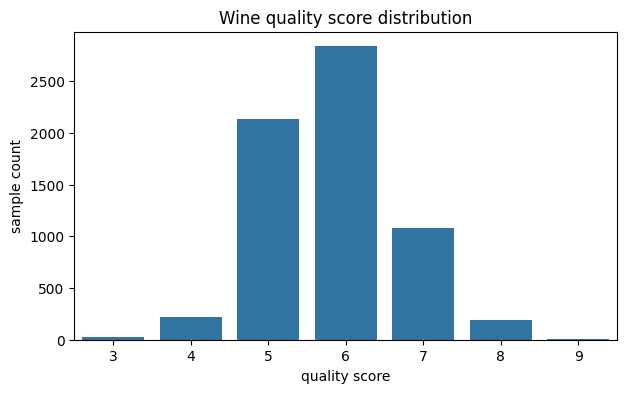

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df_wine, x="quality")
plt.title("Wine quality score distribution")
plt.xlabel("quality score")
plt.ylabel("sample count")
plt.show()

In [ ]:
print("Rice Classü sample Ú")
display(df_rice["Class"].value_counts())

Rice Classü sample Ú


,count
Class,
Osmancik,2180
Cammeo,1630


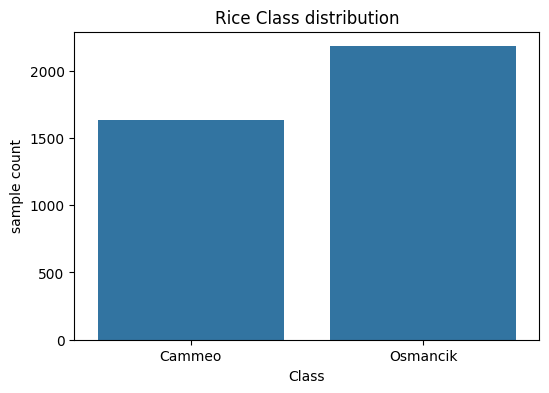

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_rice, x="Class")
plt.title("Rice Class distribution")
plt.xlabel("Class")
plt.ylabel("sample count")
plt.show()

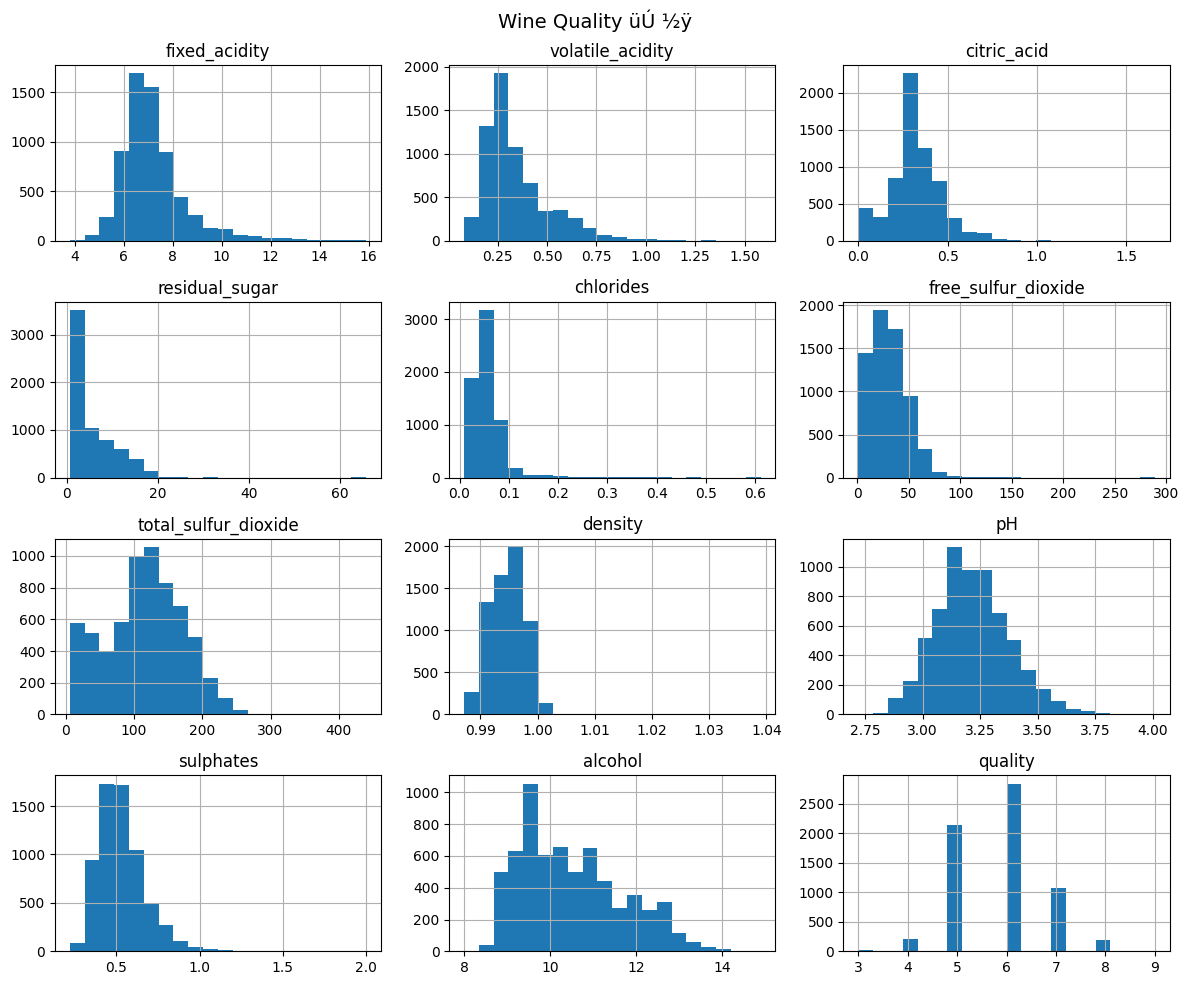

In [ ]:
df_wine.hist(figsize=(12, 10), bins=20)
plt.suptitle("Wine Quality üÚ ½ÿ", fontsize=14)
plt.tight_layout()
plt.show()

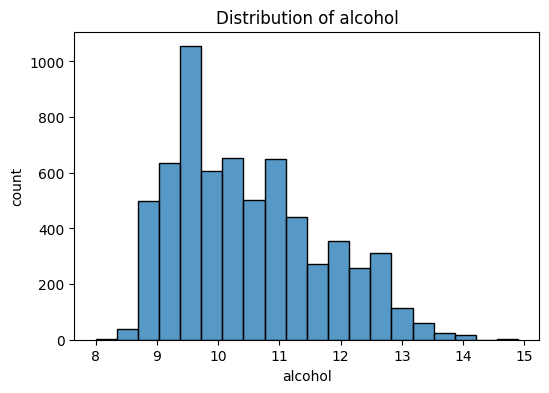

In [ ]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df_wine, x="alcohol", bins=20)
plt.title("Distribution of alcohol")
plt.xlabel("alcohol")
plt.ylabel("count")
plt.show()

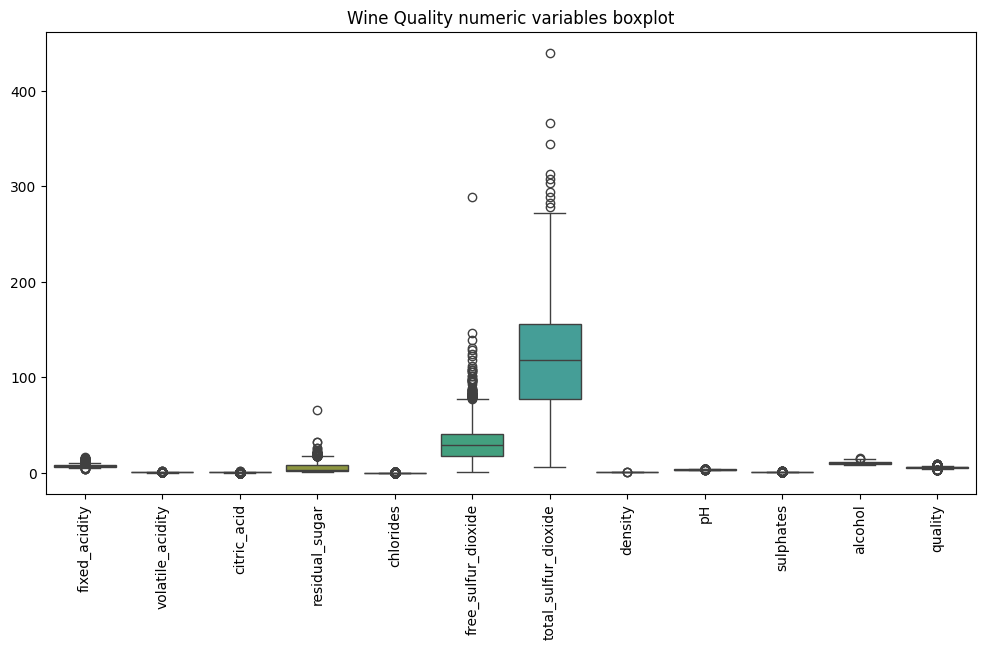

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_wine.select_dtypes(include="number"))
plt.xticks(rotation=90)
plt.title("Wine Quality numeric variables boxplot")
plt.show()

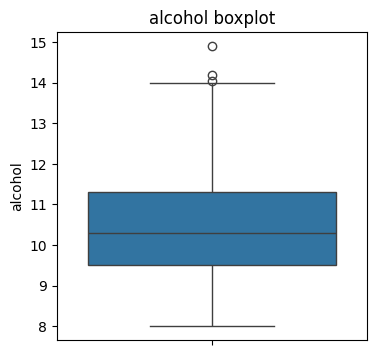

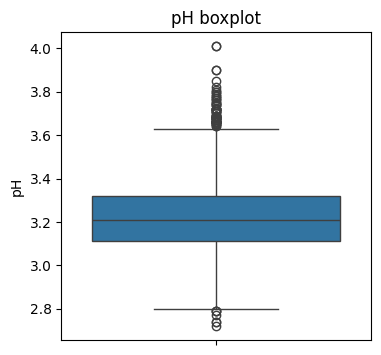

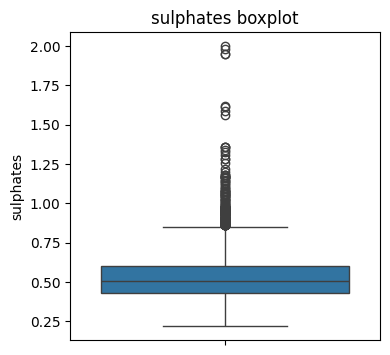

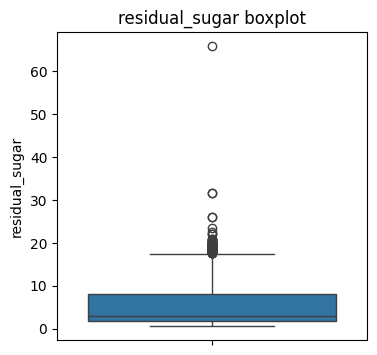

In [ ]:
features_to_plot = ["alcohol", "pH", "sulphates", "residual_sugar"]

for col in features_to_plot:
  plt.figure(figsize=(4, 4))
  sns.boxplot(y=df_wine[col])
  plt.title(f"{col} boxplot")
  plt.ylabel(col)
  plt.show()

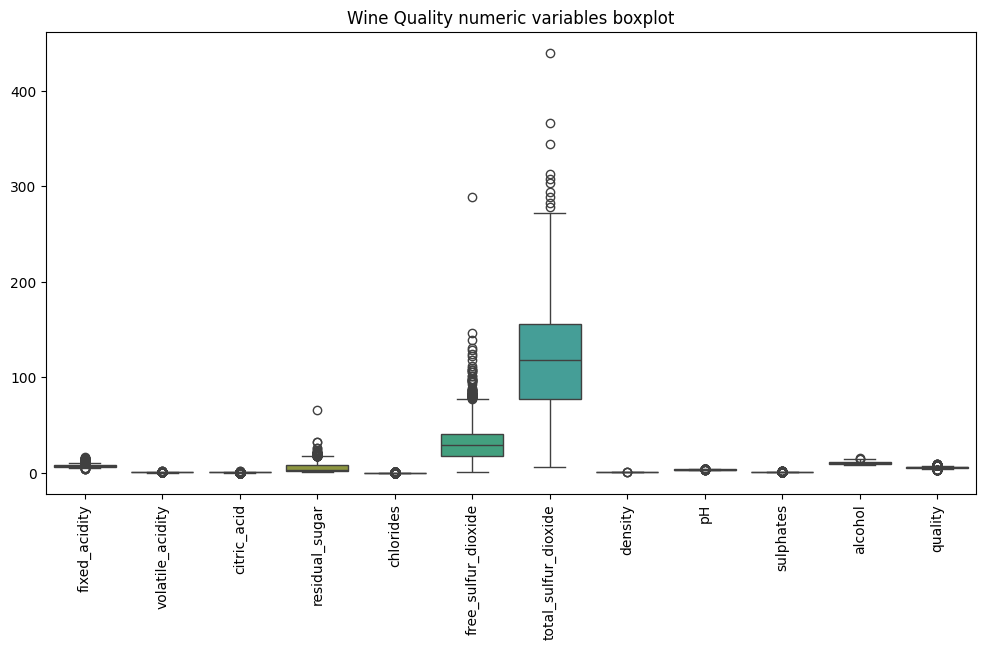

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_wine.select_dtypes(include="number"))
plt.xticks(rotation=90)
plt.title("Wine Quality numeric variables boxplot")
plt.show()

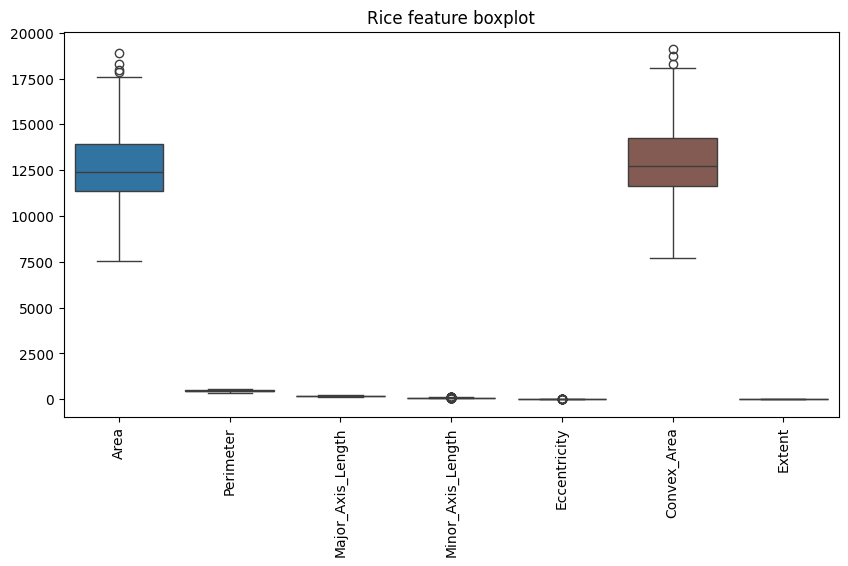

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_rice.drop(columns=["Class"]))
plt.xticks(rotation=90)
plt.title("Rice feature boxplot")
plt.show()

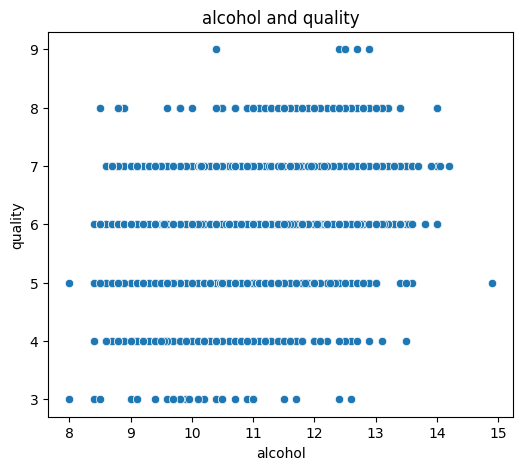

In [ ]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df_wine, x="alcohol", y="quality")
plt.title("alcohol and quality")
plt.xlabel("alcohol")
plt.ylabel("quality")
plt.show()

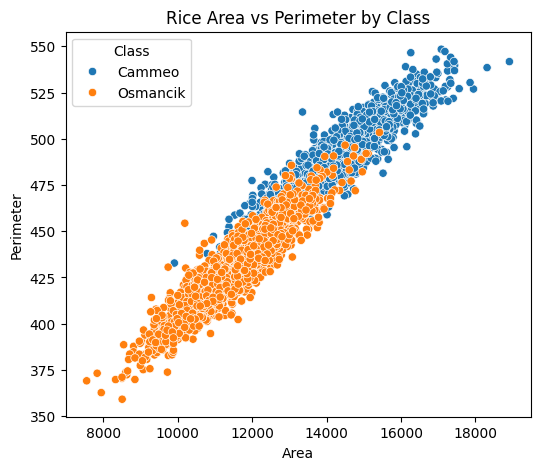

In [ ]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
 data=df_rice,
 x="Area",
 y="Perimeter",
 hue="Class"
)
plt.title("Rice Area vs Perimeter by Class")
plt.xlabel("Area")
plt.ylabel("Perimeter")
plt.show()

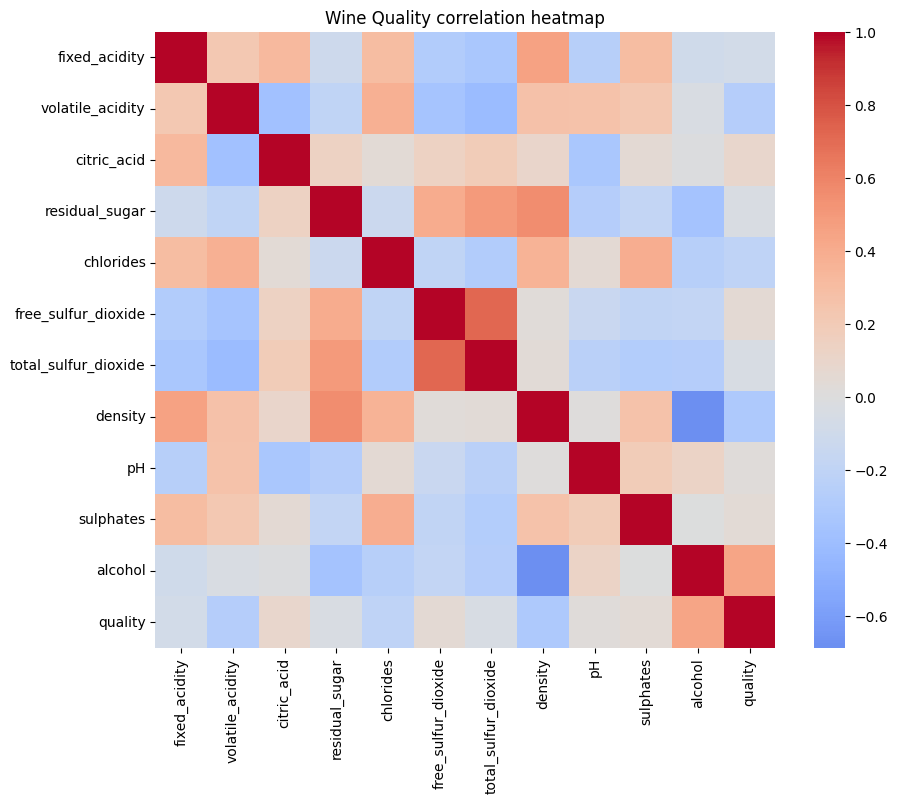

In [ ]:
corr_wine = df_wine.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(
 corr_wine,
 cmap="coolwarm",
 center=0
)
plt.title("Wine Quality correlation heatmap")
plt.show()

In [ ]:
rice_group_mean = df_rice.groupby("Class").mean(numeric_only=True)
display(rice_group_mean)

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent
Class,,,,,,,
Cammeo,14162.892025,487.438942,205.478589,88.767532,0.901047,14494.426994,0.651420
Osmancik,11549.783486,429.415505,176.287755,84.479042,0.876271,11799.585780,0.669796


In [ ]:
wine_quality_alcohol_mean = df_wine.groupby("quality")["alcohol"].mean()
display(wine_quality_alcohol_mean)

,alcohol
quality,
3,10.215000
4,10.180093
5,9.837783
6,10.587553
7,11.386006
8,11.678756
9,12.180000


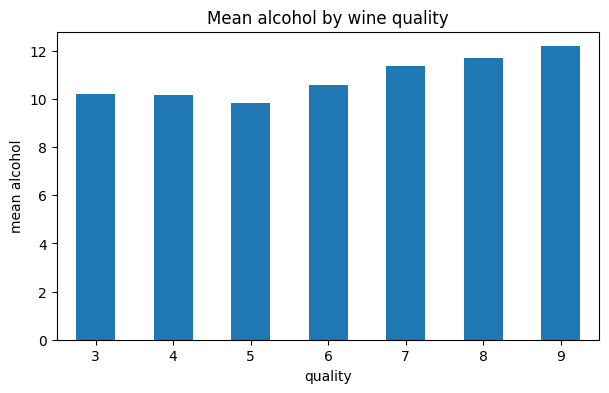

In [ ]:
plt.figure(figsize=(7, 4))
wine_quality_alcohol_mean.plot(kind="bar")
plt.title("Mean alcohol by wine quality")
plt.xlabel("quality")
plt.ylabel("mean alcohol")
plt.xticks(rotation=0)
plt.show()

In [ ]:
wine_alcohol = df_wine["alcohol"]
print("alcohol 평균:", wine_alcohol.mean())
print("alcohol 표준편차:", wine_alcohol.std())
print("평균 - 표준편차:", wine_alcohol.mean() - wine_alcohol.std())
print("평균 + 표준편차:", wine_alcohol.mean() + wine_alcohol.std())

alcohol 평균: 10.491800831149453
alcohol 표준편차: 1.1927117488689862
평균 - 표준편차: 9.299089082280467
평균 + 표준편차: 11.684512580018438


,mean,std
Class,,
Cammeo,14162.892025,1286.770521
Osmancik,11549.783486,1041.908607


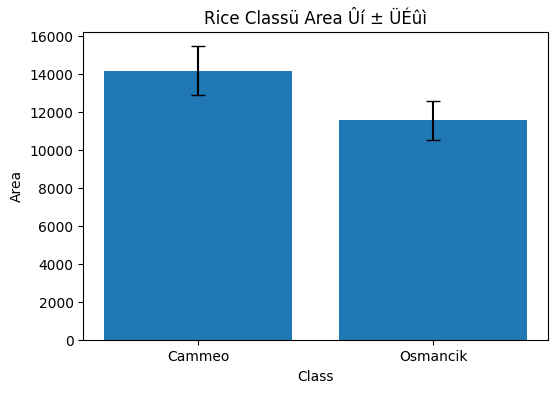

In [ ]:
area_summary = df_rice.groupby("Class")["Area"].agg(["mean", "std"])
display(area_summary)
plt.figure(figsize=(6, 4))
plt.bar(
 area_summary.index,
 area_summary["mean"],
 yerr=area_summary["std"],
 capsize=5
)
plt.title("Rice Classü Area Ûí ± ÜÉûì")
plt.xlabel("Class")
plt.ylabel("Area")
plt.show()

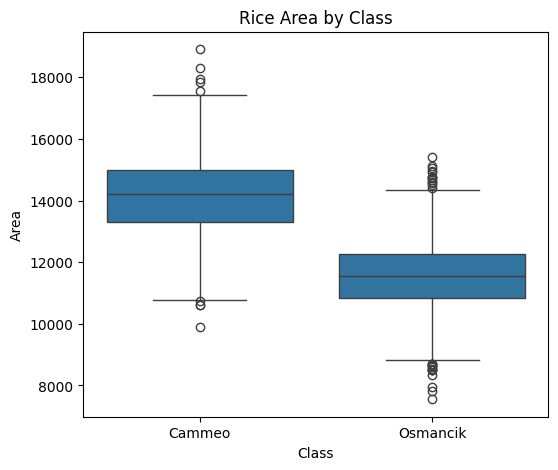

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(
 data=df_rice,
 x="Class",
 y="Area"
)
plt.title("Rice Area by Class")
plt.xlabel("Class")
plt.ylabel("Area")
plt.show()

In [ ]:
class_names = df_rice["Class"].unique()
print("Class ÷½:", class_names)
area_1 = df_rice[df_rice["Class"] == class_names[0]]["Area"]
area_2 = df_rice[df_rice["Class"] == class_names[1]]["Area"]
t_stat, p_value = stats.ttest_ind(area_1, area_2, equal_var=False)
print("t-statistic:", t_stat)
print("p-value:", p_value)

Class ÷½: ['Cammeo' 'Osmancik']
t-statistic: 67.1622793043339
p-value: 0.0


In [ ]:
selected_wine = df_wine[
 ["alcohol", "pH", "sulphates", "quality"]
]
display(selected_wine.head())

,alcohol,pH,sulphates,quality
0,9.4,3.51,0.56,5
1,9.8,3.20,0.68,5
2,9.8,3.26,0.65,5
3,9.8,3.16,0.58,6
4,9.4,3.51,0.56,5


In [ ]:
selected_wine.to_csv(
 "/content/selected_wine_quality.csv",
 index=False
)
print("저장 완료")

저장 완료


In [ ]:
import os
print("Öï /content ÷÷ ßÿ »ý:")
print(os.listdir("/content"))

Öï /content ÷÷ ßÿ »ý:
['.config', 'selected_wine_quality.csv', 'sample_data']


In [ ]:
from google.colab import files
files.download("/content/selected_wine_quality.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>